In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib
import re
from pathlib import Path

# Path ko automatically project root par set karo
BASE_DIR = Path.cwd()
if BASE_DIR.name == "notebooks":
    BASE_DIR = BASE_DIR.parent

# File path set karo
file_path = BASE_DIR / "data" / "raw" / "Labeled_Social_NLP_Training_Data.csv"

# Load the dataset
df = pd.read_csv(file_path)
print("Data Shape:", df.shape)
print("Sentiment Class Balance:\n", df['sentiment_label'].value_counts())

Data Shape: (9000, 4)
Sentiment Class Balance:
 sentiment_label
Negative    3000
Positive    3000
Neutral     3000
Name: count, dtype: int64


In [11]:
# Rulebook Requirement: Preprocessing Pipeline
def clean_text(text):
    text = str(text).lower() # Lowercase
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE) # Remove URLs
    text = re.sub(r'\@\w+|\#', '', text) # Remove mentions and hashtags (keep word)
    text = re.sub(r'[^\w\s]', '', text) # Remove punctuations
    return text

df['cleaned_text'] = df['post_text'].apply(clean_text)

# Features (X) and Target (y)
X = df['cleaned_text']
y = df['sentiment_label']

# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X_vectorized = vectorizer.fit_transform(X)

# Train-Test Split (80% Training, 20% Evaluation)
X_train, X_test, y_train, y_test = train_test_split(X_vectorized, y, test_size=0.2, random_state=42, stratify=y)
print("Preprocessing & Vectorization Complete.")

Preprocessing & Vectorization Complete.


In [12]:
# Rulebook Requirement: Model Selection & Training Methodology
# Using Logistic Regression: Excellent baseline for text classification, less prone to overfitting on TF-IDF
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
print("Model Training Complete.")

Model Training Complete.


--- EVALUATION METRICS ---
Accuracy: 0.6072

              precision    recall  f1-score   support

    Negative       0.68      0.64      0.66       600
     Neutral       0.52      0.56      0.54       600
    Positive       0.63      0.61      0.62       600

    accuracy                           0.61      1800
   macro avg       0.61      0.61      0.61      1800
weighted avg       0.61      0.61      0.61      1800



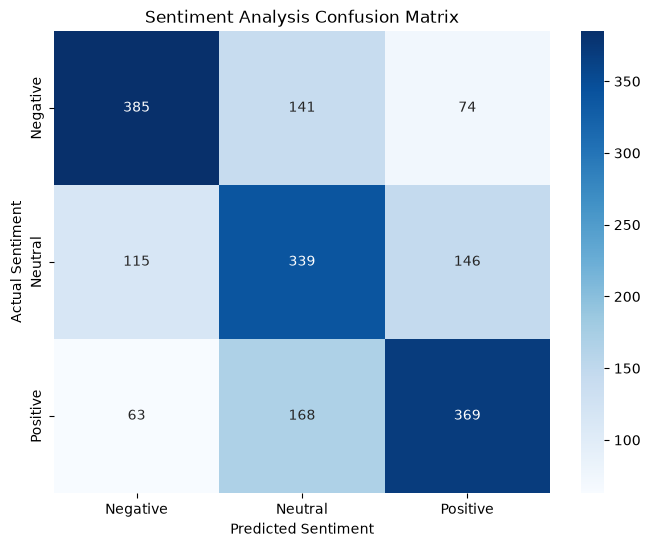

Confusion Matrix saved as 'Confusion_Matrix.png'


In [13]:
# Rulebook Requirement: Evaluation Metrics & Confusion Matrix
print("--- EVALUATION METRICS ---")
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

report = classification_report(y_test, y_pred)
print(report)

# Plot and save Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred, labels=model.classes_)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Sentiment Analysis Confusion Matrix')
plt.xlabel('Predicted Sentiment')
plt.ylabel('Actual Sentiment')
plt.savefig('Confusion_Matrix.png', bbox_inches='tight')
plt.show()
print("Confusion Matrix saved as 'Confusion_Matrix.png'")

In [14]:
# Rulebook Requirement: Error Analysis
# Find where the model predicted incorrectly
X_test_raw = df.loc[y_test.index, 'post_text']
error_df = pd.DataFrame({
    'Original_Text': X_test_raw,
    'Actual_Sentiment': y_test,
    'Predicted_Sentiment': y_pred
})

misclassified = error_df[error_df['Actual_Sentiment'] != error_df['Predicted_Sentiment']]
print(f"Total Misclassified Samples: {len(misclassified)} out of {len(y_test)}")

print("\n--- Top 5 Misclassified Examples for Error Analysis ---")
display(misclassified.head(5))

Total Misclassified Samples: 707 out of 1800

--- Top 5 Misclassified Examples for Error Analysis ---


,Original_Text,Actual_Sentiment,Predicted_Sentiment
6517,@user I still think it was fake. I always thou...,Negative,Neutral
7441,John Cena throwing Jon Stewart at the WWE is p...,Positive,Neutral
8898,"""1st this @user writer implies I copied Kpop, ...",Neutral,Negative
4141,@user @user Jeb Bush dug himself a deep hole w...,Negative,Positive
4199,Damn my best friend is not going to riot Fest ...,Negative,Positive


In [15]:
# Rulebook Requirement: Trained Model Files (.pkl)
joblib.dump(model, 'sentiment_model.pkl')
joblib.dump(vectorizer, 'tfidf_vectorizer.pkl')
print("Model and Vectorizer successfully saved as .pkl files!")

Model and Vectorizer successfully saved as .pkl files!
